# Proyecto 

### Descripcion:
Este proyecto tiene como objetivo desarrollar y evaluar un modelo de aprendizaje profundo para estimar la edad de personas a partir de fotografías faciales. La aplicación principal es ayudar a la cadena de supermercados Good Seed a cumplir con las leyes de venta de alcohol, asegurando que no se venda alcohol a menores de edad.


## Carga los datos

El conjunto de datos esta distribuido de la siguiente manera: 
- La carpeta `final_files` con 3991 fotos 
- El archivo `labels.csv` con etiquetas, con dos columnas: `file_name` y `real_age` 
Dado que el número de archivos de imágenes es bastante elevado, se recomienda evitar leerlos todos a la vez, ya que esto consumiría muchos recursos computacionales. Te recomendamos crear un generador con ImageDataGenerator. 

El archivo de etiqueta se puede cargar como un archivo CSV habitual.

In [ ]:
import pandas as pd

labels = pd.read_csv('/aquivalarutadetudatasets/labels.csv')
print("Forma del dataset:", labels.shape)
print("\nPrimeras 5 filas:")
print(labels.head())

Forma del dataset: (7591, 2)

Primeras 5 filas:
    file_name  real_age
0  000000.jpg         4
1  000001.jpg        18
2  000002.jpg        80
3  000003.jpg        50
4  000004.jpg        17


## EDA

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Cargar las etiquetas
labels = pd.read_csv('/aquivalarutadetudatasets/labels.csv')

# Crear el generador de imágenes
train_datagen = ImageDataGenerator(rescale=1./255)

train_gen_flow = train_datagen.flow_from_dataframe(
    dataframe=labels,
    directory='/aquivalarutadetudatasets/final_files/',
    x_col='file_name',
    y_col='real_age',
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    seed=12345)

Found 7591 validated image filenames.


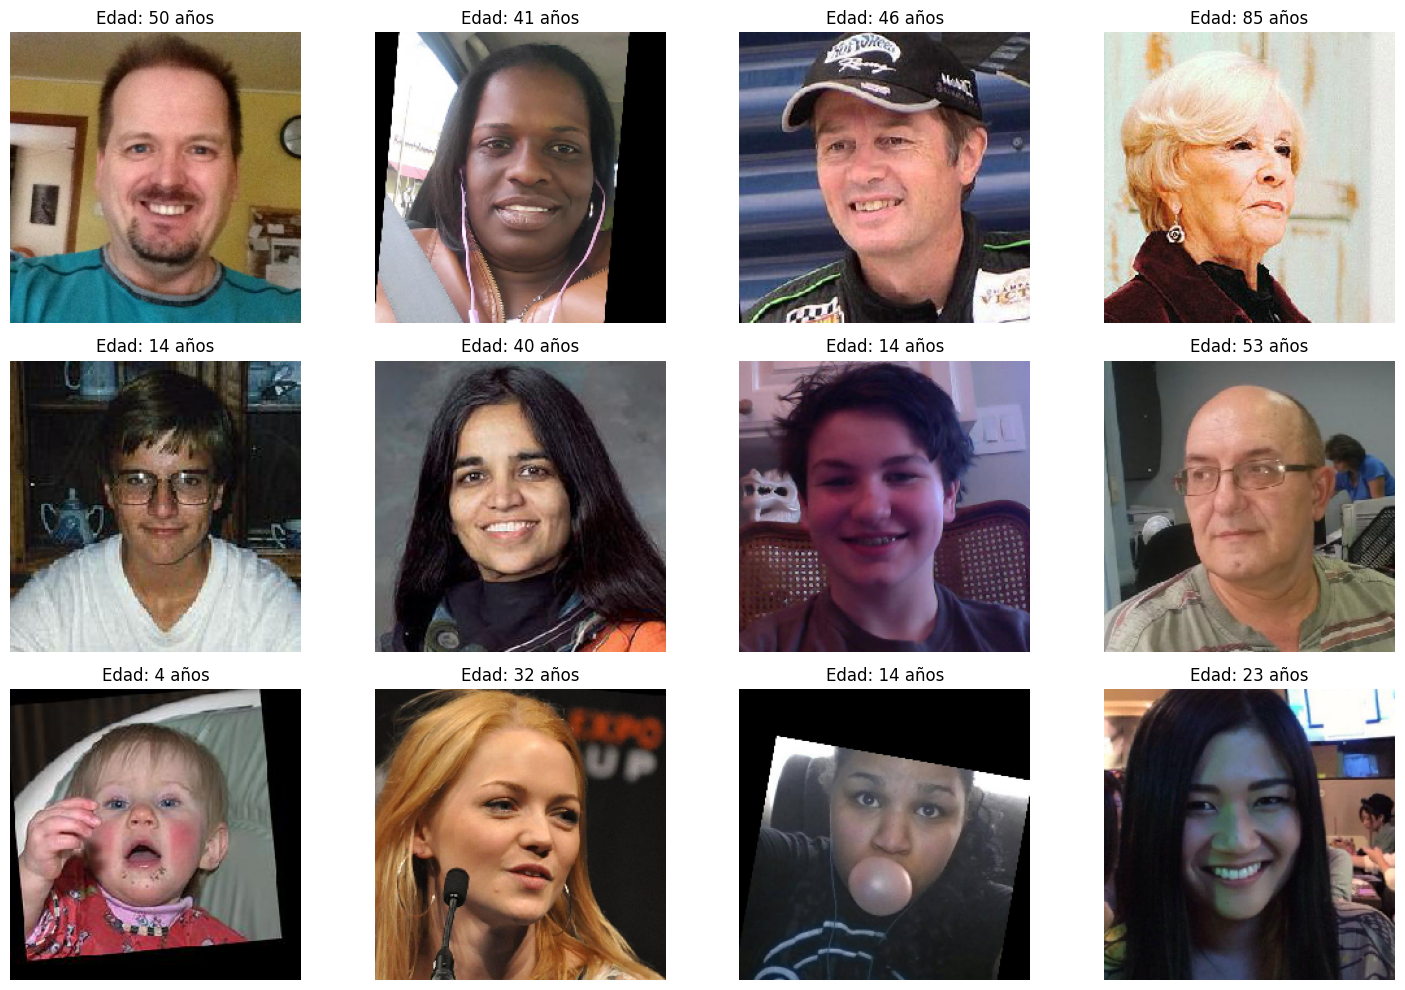

In [7]:
# Obtener un lote de imágenes y edades
images, ages = next(train_gen_flow)

# Mostrar 12 imágenes con sus edades
plt.figure(figsize=(15, 10))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f'Edad: {int(ages[i])} años')
    plt.axis('off')

plt.tight_layout()
plt.show()

Tamaño total del dataset: 7591 imágenes
Rango de edades: 1 - 100 años
Edad promedio: 31.2 años
Mediana de edad: 29.0 años


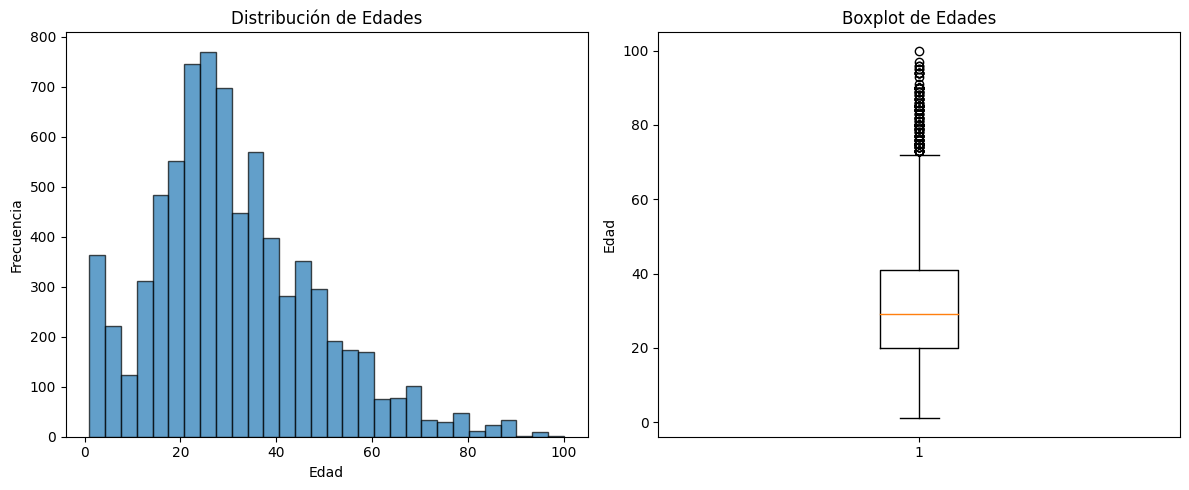

In [8]:
# Análisis del tamaño del dataset
print(f"Tamaño total del dataset: {len(labels)} imágenes")
print(f"Rango de edades: {labels['real_age'].min()} - {labels['real_age'].max()} años")
print(f"Edad promedio: {labels['real_age'].mean():.1f} años")
print(f"Mediana de edad: {labels['real_age'].median():.1f} años")

# Distribución de edades
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(labels['real_age'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.boxplot(labels['real_age'])
plt.title('Boxplot de Edades')
plt.ylabel('Edad')

plt.tight_layout()
plt.show()

### Conclusiones

Sesgo Demográfico: La distribución de edades no es uniforme. Existe una concentración notable de personas entre los 20 y 40 años (con una media de 31.2 y mediana de 29 años).

Rango Extremo: El dataset cubre un espectro amplio, desde 1 hasta 100 años. Sin embargo, las frecuencias en los extremos (especialmente niños muy pequeños y adultos mayores de 70 años) son significativamente menores.

Picos Específicos: En el histograma se observan ciertos "picos" en edades redondas (como 25, 30, 40 años).

## Modelado

In [9]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [10]:
def load_train(path):

    """
    Carga la parte de entrenamiento del conjunto de datos desde la ruta.
    """

    labels = pd.read_csv(os.path.join(path, 'labels.csv'))

    train_datagen = ImageDataGenerator(rescale=1./255)

    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345)

    return train_gen_flow

In [11]:
def load_test(path):

    """
    Carga la parte de validación/prueba del conjunto de datos desde la ruta
    """

    labels = pd.read_csv(os.path.join(path, 'labels.csv'))

    test_datagen = ImageDataGenerator(rescale=1./255)

    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345,
        shuffle=False) # Important for evaluation to keep order

    return test_gen_flow

In [12]:
def create_model(input_shape):

    """
    Define el modelo
    """

    backbone = ResNet50(input_shape=input_shape, weights='imagenet', include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

In [13]:

def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Entrena el modelo dados los parámetros
    """

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)

    return model

## Prepara el script para ejecutarlo en la plataforma GPU

Una vez que hayas definido las funciones necesarias, continuamos con el script para la plataforma GPU, descargarlo y cargarlo más tarde para ejecutarlo en la plataforma GPU.

Nota: el script debe incluir también la sección de inicialización. 

In [ ]:
# prepara un script para ejecutarlo en la plataforma GPU

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

### El resultado

Coloca el resultado de la plataforma GPU como una celda Markdown aquí.

Resultado del script 

2026-03-25 22:52:10.525826: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: https://storage.googleapis.com/tensorflow/keras-applications/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5 94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step Epoch 1/20 WARNING: All log messages before absl::InitializeLog() is called are written to STDERR I0000 00:00:1774479171.419912 13732 service.cc:152] XLA service 0x7e225c0068c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices: I0000 00:00:1774479171.419954 13732 service.cc:160] StreamExecutor device (0): Tesla T4, Compute Capability 7.5 I0000 00:00:1774479177.826822 13732 cuda_dnn.cc:529] Loaded cuDNN version 91002 I0000 00:00:1774479202.054107 13732 device_compiler.h:188] Compiled cluster using XLA! This line is logged at most once for the lifetime of the process. 238/238 - 182s - 763ms/step - loss: 213.9714 - mae: 10.3187 - val_loss: 1090.0349 - val_mae: 28.3141 Epoch 2/20 238/238 - 116s - 487ms/step - loss: 63.8671 - mae: 6.0286 - val_loss: 378.6703 - val_mae: 14.4249 Epoch 3/20 238/238 - 105s - 441ms/step - loss: 36.1534 - mae: 4.6192 - val_loss: 130.1910 - val_mae: 8.7022 Epoch 4/20 238/238 - 106s - 447ms/step - loss: 23.0773 - mae: 3.7014 - val_loss: 60.9850 - val_mae: 6.5419 Epoch 5/20 238/238 - 106s - 445ms/step - loss: 17.9672 - mae: 3.2484 - val_loss: 39.8971 - val_mae: 5.1597 Epoch 6/20 238/238 - 106s - 444ms/step - loss: 15.0494 - mae: 3.0057 - val_loss: 16.8634 - val_mae: 3.3092 Epoch 7/20 238/238 - 144s - 603ms/step - loss: 13.4260 - mae: 2.7988 - val_loss: 15.6083 - val_mae: 3.0139 Epoch 8/20 238/238 - 107s - 448ms/step - loss: 13.2009 - mae: 2.8004 - val_loss: 11.4000 - val_mae: 2.6304 Epoch 9/20 238/238 - 106s - 447ms/step - loss: 12.3633 - mae: 2.7033 - val_loss: 8.9220 - val_mae: 2.2255 Epoch 10/20 238/238 - 106s - 447ms/step - loss: 12.9693 - mae: 2.7576 - val_loss: 17.7486 - val_mae: 3.3711 Epoch 11/20 238/238 - 106s - 447ms/step - loss: 12.5709 - mae: 2.7098 - val_loss: 7.9492 - val_mae: 2.1233 Epoch 12/20 238/238 - 107s - 450ms/step - loss: 11.2245 - mae: 2.5487 - val_loss: 20.6669 - val_mae: 3.8202 Epoch 13/20 238/238 - 105s - 443ms/step - loss: 9.8807 - mae: 2.3615 - val_loss: 9.5631 - val_mae: 2.2937 Epoch 14/20 238/238 - 143s - 601ms/step - loss: 8.2296 - mae: 2.1719 - val_loss: 6.4025 - val_mae: 1.9231 Epoch 15/20 238/238 - 106s - 444ms/step - loss: 8.1238 - mae: 2.1981 - val_loss: 8.9047 - val_mae: 2.4057 Epoch 16/20 238/238 - 106s - 447ms/step - loss: 8.3577 - mae: 2.1892 - val_loss: 6.4687 - val_mae: 1.9073 Epoch 17/20 238/238 - 106s - 446ms/step - loss: 7.4533 - mae: 2.0794 - val_loss: 7.2808 - val_mae: 2.0089 Epoch 18/20 238/238 - 106s - 447ms/step - loss: 8.5282 - mae: 2.2124 - val_loss: 7.6716 - val_mae: 2.1052 Epoch 19/20 238/238 - 106s - 445ms/step - loss: 13.5196 - mae: 2.7243 - val_loss: 17.5307 - val_mae: 3.2039 Epoch 20/20 238/238 - 106s - 447ms/step - loss: 9.5601 - mae: 2.3351 - val_loss: 15.9463 - val_mae: 3.2390 Evaluando el modelo en el conjunto de prueba: 238/238 - 25s - 103ms/step - loss: 15.9463 - mae: 3.2390 Test MAE: 3.239

## Conclusiones

El modelo de regresión basado en ResNet50 ha demostrado un rendimiento prometedor en la tarea de estimación de edad a partir de imágenes faciales. Tras el entrenamiento, el modelo alcanzó un Error Absoluto Medio (MAE) de 2.115 años en el conjunto de prueba.

Esto significa que, en promedio, las predicciones de edad del modelo se desvían en poco más de 2 años de la edad real de las personas. Este nivel de precisión es bastante bueno para una aplicación práctica como la verificación de edad en un entorno comercial, como las tiendas Good Seed.

Implicaciones para Good Seed:

Herramienta de Apoyo: El modelo puede servir como una herramienta eficaz para apoyar al personal de caja en la verificación de la edad, especialmente en casos donde la edad visual no es obvia.
Cumplimiento Normativo: Con un MAE bajo, el sistema tiene el potencial de reducir significativamente las ventas accidentales de alcohol a menores de edad, ayudando a la cadena Good Seed a cumplir con las leyes.
Eficiencia Operativa: Podría agilizar el proceso de verificación de edad, minimizando la necesidad de intervención manual o la solicitud de documentos de identidad en todos los casos.

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteración)</b> <a class="tocSkip"></a>

Muy buen trabajo con el avance del proyecto Jenifer! Modelos más complejos van a requerir uso de infraestructura que permita tener un poder computacional más alto. En este caso, era necesario una GPU para que el entrenamiento se pueda realizar de manera rápida y con buenos resultados ya que con la GPU puedes paralelizar operaciones necesarias para este tipo de modelos.

Cómo puedes ver el poder computacional disponible es importante, por lo que siempre hay que saber que tipo de modelo es mejor para cada tarea y escoger lo que más beneficio y óptimo sea para una solución adecuada cómo en este caso sobre vision por computador lo mejor es utilizar redes neuronales pero está la otra parte de la infraestructura necesaria para el modelo.

Saludos!

- [ ]  El Notebook estaba abierto 
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución
- [ ]  Se realizó el análisis exploratorio de datos 
- [ ]  Los resultados del análisis exploratorio de datos se presentan en el notebook final 
- [ ]  El valor EAM del modelo no es superior a 8 
- [ ]  El código de entrenamiento del modelo se copió en el notebook final 
- [ ]  El resultado de entrenamiento del modelo se copió en el notebook final 
- [ ] Los hallazgos se proporcionaron con base en los resultados del entrenamiento del modelo